# DodoGo Driver Value, Survival and Churn Risk (NB06)

This notebook studies the supply side of the DodoGo marketplace. It connects driver value concentration, driver survival, churn prediction and risk prioritization with a smaller customer-value section.

| Block | Method | Main result |
|---|---|---|
| Driver value | Relative value and Pareto analysis | Top driver group contributes most platform value |
| Driver survival | Kaplan-Meier | High-volume drivers stay active longer |
| Driver churn | Gradient Boosting | Baseline CV AUC = 0.806 |
| Early-warning model | Trend features with pre-cutoff window | Combined CV AUC = 0.887 |
| Risk matrix | Value index x churn probability | 21 high-value at-risk drivers |
| Customer value | Relative LTV and conversion opportunity | Bonus users show higher observed value |

Exact monetary amounts are not shown in the public version. Value-related outputs are reported as indexes, shares or ratios.


## Setup: Data Loading and Preparation

The setup loads driver, order and client tables and creates derived fields used in the later analysis. Raw identifiers are used only for joins inside the notebook; no individual driver or client records are printed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load driver table
df_drv = pd.read_csv("../data/raw/drivers.csv", sep=";", encoding="windows-1251")
df_drv['name'] = df_drv['Исполнитель'].str.strip('=" ')
df_drv['callsign'] = df_drv['Позывной'].str.strip('=" ').astype(int)
df_drv['efficiency'] = df_drv['Эффективность'].str.replace(',', '.').astype(float)
df_drv['revenue'] = df_drv['Стоимость'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['commission'] = df_drv['Комиссия исполнителя'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['cash'] = df_drv['Наличные'].astype(str).str.replace(',', '.').str.replace(' ', '').astype(float)
df_drv['completed'] = df_drv['Завершенные заказы']
df_drv['cancelled'] = df_drv['Отмененные заказы']
df_drv['total'] = df_drv['Всего заказов']

def parse_hours(s):
    if pd.isna(s): return None
    m = re.match(r'(\d+)\s*ч\s*(?:(\d+)\s*мин)?', str(s))
    return int(m.group(1)) + int(m.group(2) or 0)/60 if m else None
df_drv['hours_online'] = df_drv['Время на линии'].apply(parse_hours)

# Derived driver metrics
df_drv['cancel_rate'] = df_drv['cancelled'] / df_drv['total'].replace(0, np.nan)
df_drv['commission_rate'] = df_drv['commission'] / df_drv['revenue'].replace(0, np.nan)
df_drv['rev_per_trip'] = df_drv['revenue'] / df_drv['completed'].replace(0, np.nan)
df_drv['order_value'] = df_drv['revenue']

# Active drivers
active = df_drv[df_drv['completed'] > 0].copy()

# Load order table
df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_new['date'] = pd.to_datetime(df_new['Дата создания'], format='%d.%m.%Y %H:%M', errors='coerce')
for col in ['Стоимость', 'Суммарное расстояние (км)']:
    df_new[col] = df_new[col].astype(str).str.replace(',', '.').astype(float)

# Load client table
raw_cli = pd.read_csv("../data/raw/clients.csv", sep=";", encoding="windows-1251", low_memory=False)
bonus_col = [c for c in raw_cli.columns if 'Бонусный баланс' in c][-1]
client_cols = ['Фамилия','Имя','Телефон','Дата рождения','Эл почта организации',
               'Успешные заказы','Неуспешные заказы', bonus_col]
df_cli = raw_cli[client_cols].copy()
df_cli.columns = ['last_name', 'first_name', 'phone', 'birth_date', 'email',
                   'successful_orders', 'failed_orders', 'bonus_balance']
df_cli['successful_orders'] = pd.to_numeric(df_cli['successful_orders'], errors='coerce').fillna(0)
df_cli['failed_orders'] = pd.to_numeric(df_cli['failed_orders'], errors='coerce').fillna(0)
df_cli['bonus_balance'] = pd.to_numeric(df_cli['bonus_balance'].astype(str).str.replace(',', '.').str.replace(' ', ''), errors='coerce').fillna(0)

print(f"Drivers loaded: {len(df_drv)} total, {len(active)} active drivers")
print(f"Orders loaded: {len(df_new):,} rows from the new platform")
print(f"Clients loaded: {len(df_cli):,}")
print("\nDriver setup summary:")
print(f"  Active-driver share: {len(active)/len(df_drv)*100:.1f}%")
print(f"  Median completed orders: {active['completed'].median():.0f}")
print("  Exact monetary totals are omitted in the saved notebook.")

Drivers loaded: 673 total, 601 active drivers
Orders loaded: 116,958 rows from the new platform
Clients loaded: 34,968

Driver setup summary:
  Active-driver share: 89.3%
  Median completed orders: 51
  Exact monetary totals are omitted in the saved notebook.


## 1. Driver Value Analysis

Drivers contribute unevenly to marketplace supply. The goal of this block is to understand value concentration without exposing exact monetary figures. The public version therefore reports value indexes, shares and tiers instead of absolute revenue amounts.


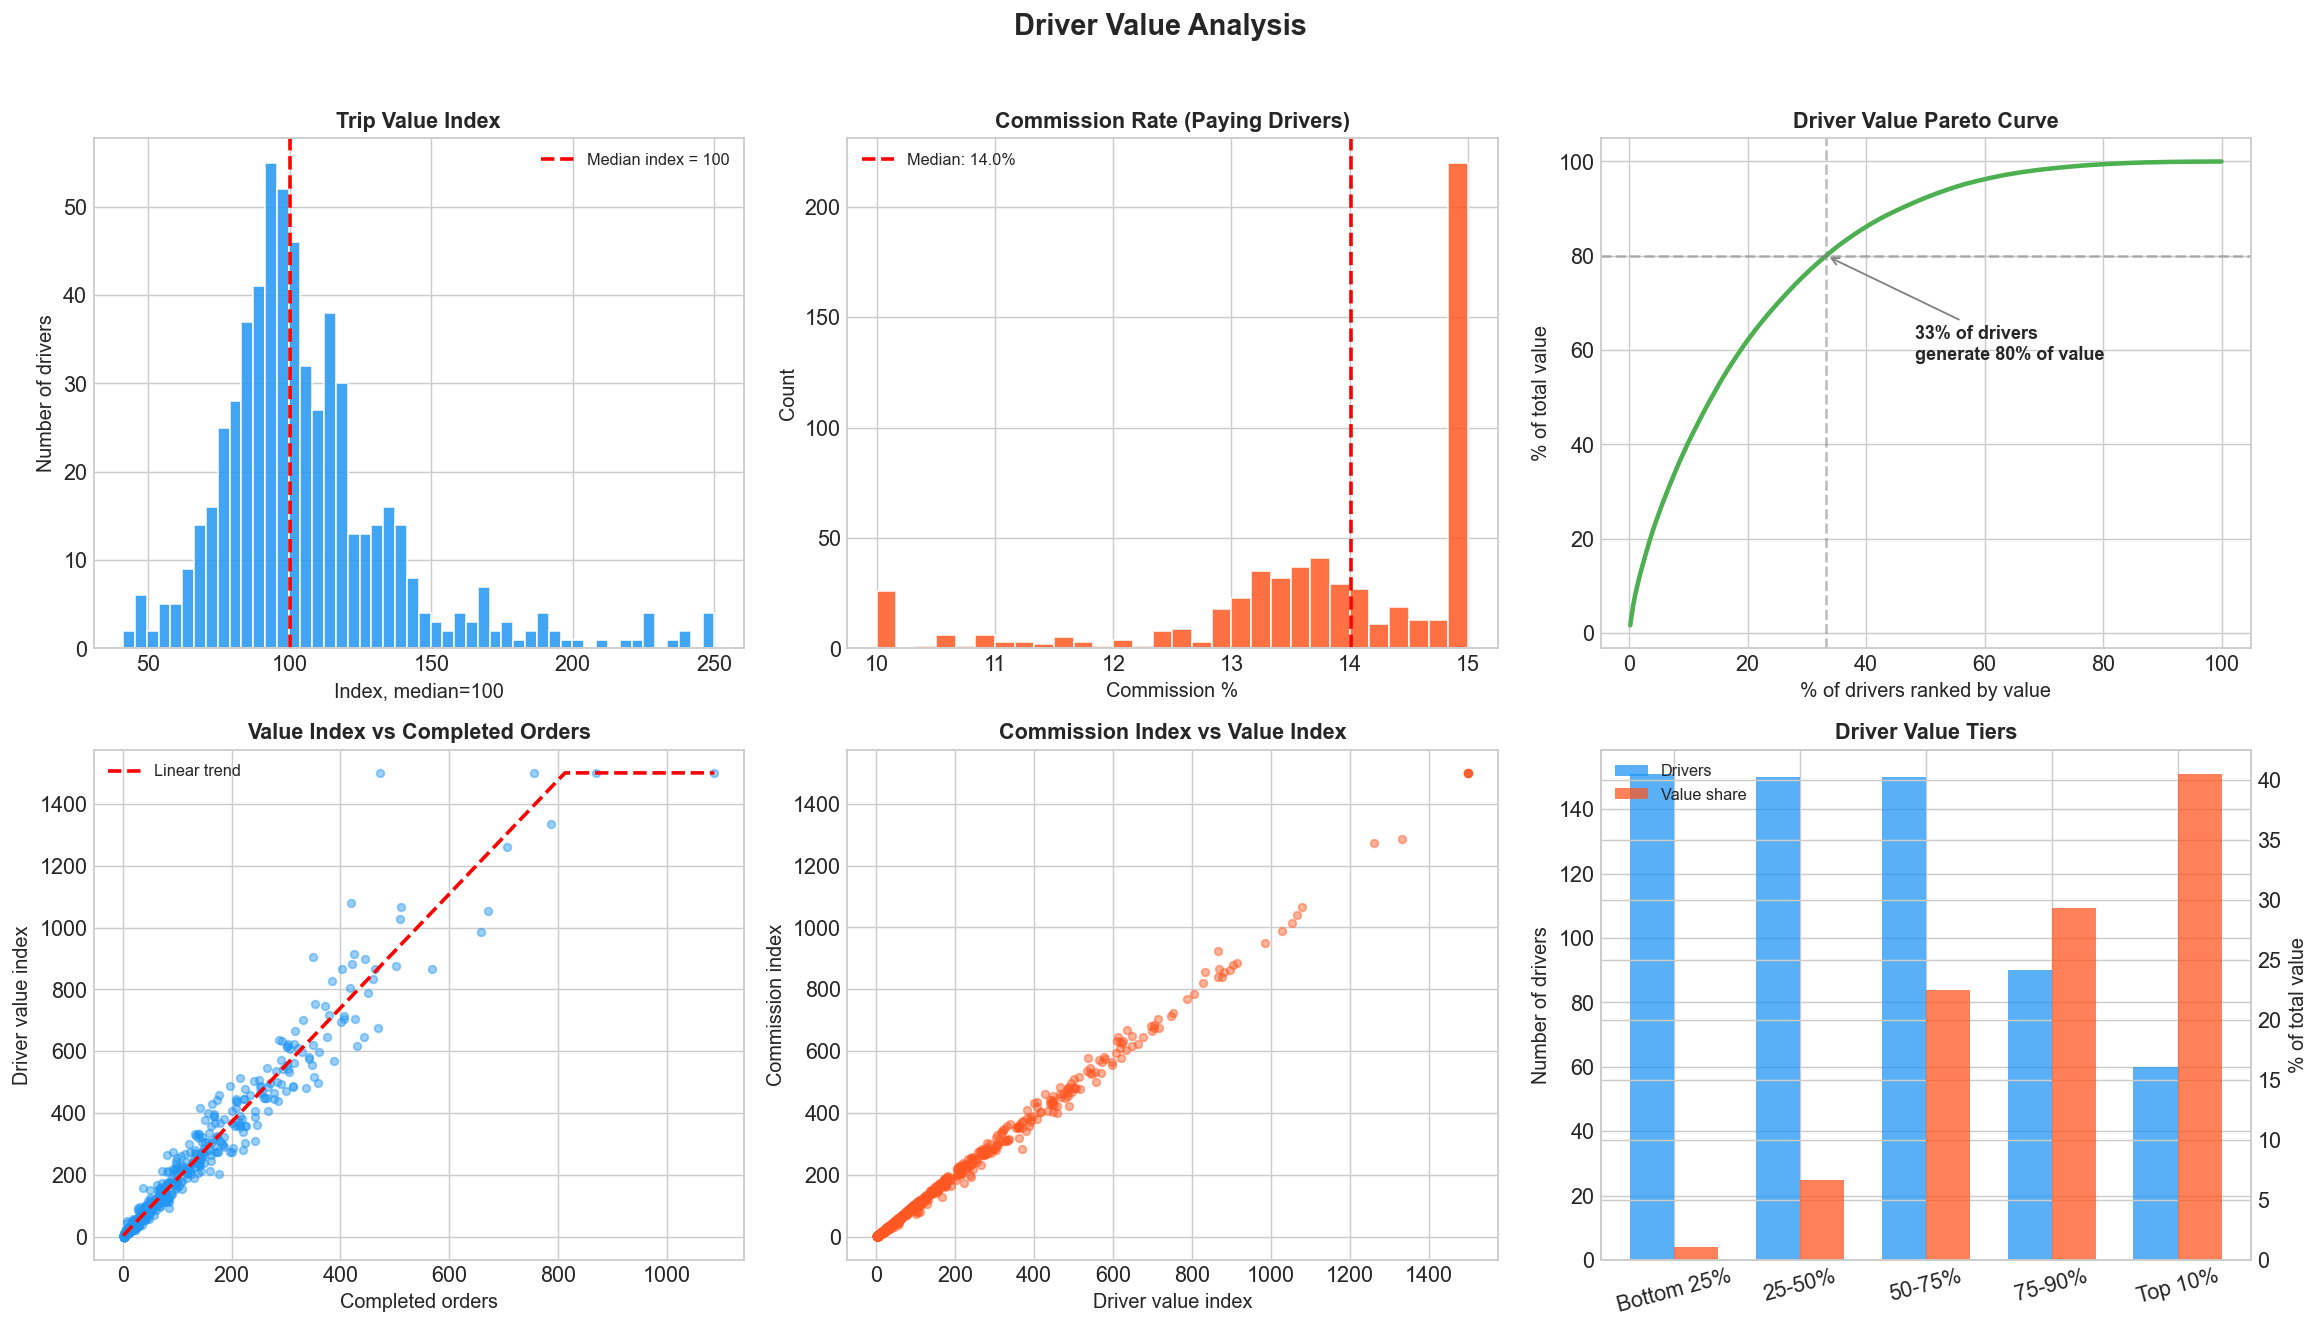


DRIVER VALUE SUMMARY
Active drivers: 601
Trip value index: median 100, mean 108
Commission rate (paying): median 14.0%
Pareto: top 33% of drivers generate 80% of value
Exact monetary value per trip and total value are omitted.

Value tier breakdown:
    Bottom 25%:  151 drivers,   1.0% of value
        25-50%:  150 drivers,   6.7% of value
        50-75%:  150 drivers,  22.5% of value
        75-90%:   90 drivers,  29.3% of value
       Top 10%:   60 drivers,  40.5% of value


In [ ]:
# Driver value analysis
active['driver_value_index'] = active['revenue'] / active['revenue'].median() * 100
active['trip_value_index'] = active['rev_per_trip'] / active['rev_per_trip'].median() * 100
active['commission_index'] = active['commission'] / active['commission'].replace(0, np.nan).median() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Trip value index distribution
ax = axes[0, 0]
valid_tvi = active['trip_value_index'].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(valid_tvi.clip(upper=250), bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(100, color='red', linestyle='--', linewidth=2, label='Median index = 100')
ax.set_title('Trip Value Index', fontweight='bold')
ax.set_xlabel('Index, median=100')
ax.set_ylabel('Number of drivers')
ax.legend()

# Commission rate distribution
ax = axes[0, 1]
paying = active[active['commission'] > 0].copy()
ax.hist(paying['commission_rate'].dropna() * 100, bins=30, color='#FF5722', alpha=0.8, edgecolor='white')
ax.axvline(paying['commission_rate'].dropna().median() * 100, color='red', linestyle='--', linewidth=2,
           label=f'Median: {paying["commission_rate"].dropna().median()*100:.1f}%')
ax.set_title('Commission Rate (Paying Drivers)', fontweight='bold')
ax.set_xlabel('Commission %')
ax.set_ylabel('Count')
ax.legend()

# Value Pareto
ax = axes[0, 2]
sorted_value = active['revenue'].sort_values(ascending=False).reset_index(drop=True)
cum_value = sorted_value.cumsum() / sorted_value.sum() * 100
driver_pct = np.arange(1, len(sorted_value)+1) / len(sorted_value) * 100
ax.plot(driver_pct, cum_value, color='#4CAF50', linewidth=2.5)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
idx_80 = np.argmax(cum_value >= 80)
pct_80 = driver_pct[idx_80]
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'{pct_80:.0f}% of drivers\ngenerate 80% of value',
            xy=(pct_80, 80), xytext=(pct_80+15, 60), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Driver Value Pareto Curve', fontweight='bold')
ax.set_xlabel('% of drivers ranked by value')
ax.set_ylabel('% of total value')

# Driver value index vs completed orders
ax = axes[1, 0]
ax.scatter(active['completed'], active['driver_value_index'], alpha=0.4, s=15, color='#2196F3')
from numpy.polynomial.polynomial import polyfit
mask = active['completed'].notna() & active['driver_value_index'].notna()
b, m = polyfit(active.loc[mask, 'completed'], active.loc[mask, 'driver_value_index'], 1)
x_fit = np.linspace(0, active['completed'].max(), 100)
ax.plot(x_fit, b + m * x_fit, color='red', linewidth=2, linestyle='--', label='Linear trend')
ax.set_title('Value Index vs Completed Orders', fontweight='bold')
ax.set_xlabel('Completed Orders')
ax.set_ylabel('Driver value index')
ax.legend()

# Commission index vs value index
ax = axes[1, 1]
ax.scatter(active['driver_value_index'], active['commission_index'], alpha=0.4, s=15, color='#FF5722')
ax.set_title('Commission Index vs Value Index', fontweight='bold')
ax.set_xlabel('Driver value index')
ax.set_ylabel('Commission index')

# Driver value tiers
ax = axes[1, 2]
q25 = active['revenue'].quantile(0.25)
q50 = active['revenue'].quantile(0.50)
q75 = active['revenue'].quantile(0.75)
q90 = active['revenue'].quantile(0.90)
active['value_tier'] = pd.cut(active['revenue'], bins=[-1, q25, q50, q75, q90, float('inf')],
                              labels=['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%'])
tier_counts = active['value_tier'].value_counts().reindex(['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%'])
tier_value = active.groupby('value_tier')['revenue'].sum().reindex(tier_counts.index)
tier_pct = tier_value / tier_value.sum() * 100
x = np.arange(len(tier_counts))
w = 0.35
ax.bar(x - w/2, tier_counts.values, w, label='Drivers', color='#2196F3', alpha=0.7)
ax2 = ax.twinx()
ax2.bar(x + w/2, tier_pct.values, w, label='Value share', color='#FF5722', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(tier_counts.index, rotation=15)
ax.set_title('Driver Value Tiers', fontweight='bold')
ax.set_ylabel('Number of drivers')
ax2.set_ylabel('% of total value')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Driver Value Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print('DRIVER VALUE SUMMARY')
print(f"{'='*60}")
print(f"Active drivers: {len(active)}")
print(f"Trip value index: median 100, mean {valid_tvi.mean():.0f}")
print(f"Commission rate (paying): median {paying['commission_rate'].dropna().median()*100:.1f}%")
print(f"Pareto: top {pct_80:.0f}% of drivers generate 80% of value")
print('Exact monetary value per trip and total value are omitted.')
print('\nValue tier breakdown:')
for tier in ['Bottom 25%', '25-50%', '50-75%', '75-90%', 'Top 10%']:
    n = tier_counts[tier]
    pct = tier_pct[tier]
    print(f"  {tier:>12}: {n:>4} drivers, {pct:>5.1f}% of value")


## 2. Driver Survival Analysis

Driver survival estimates how long drivers remain active after their first completed trip. A driver is treated as churned if there is no completed trip in the last 30 days of the observation window.

This mirrors the customer survival analysis from NB04, but applies it to the supply side of the marketplace.


Drivers in new platform: 602
Churned (no trip in 30 days): 169 (28.1%)
Active: 433 (71.9%)


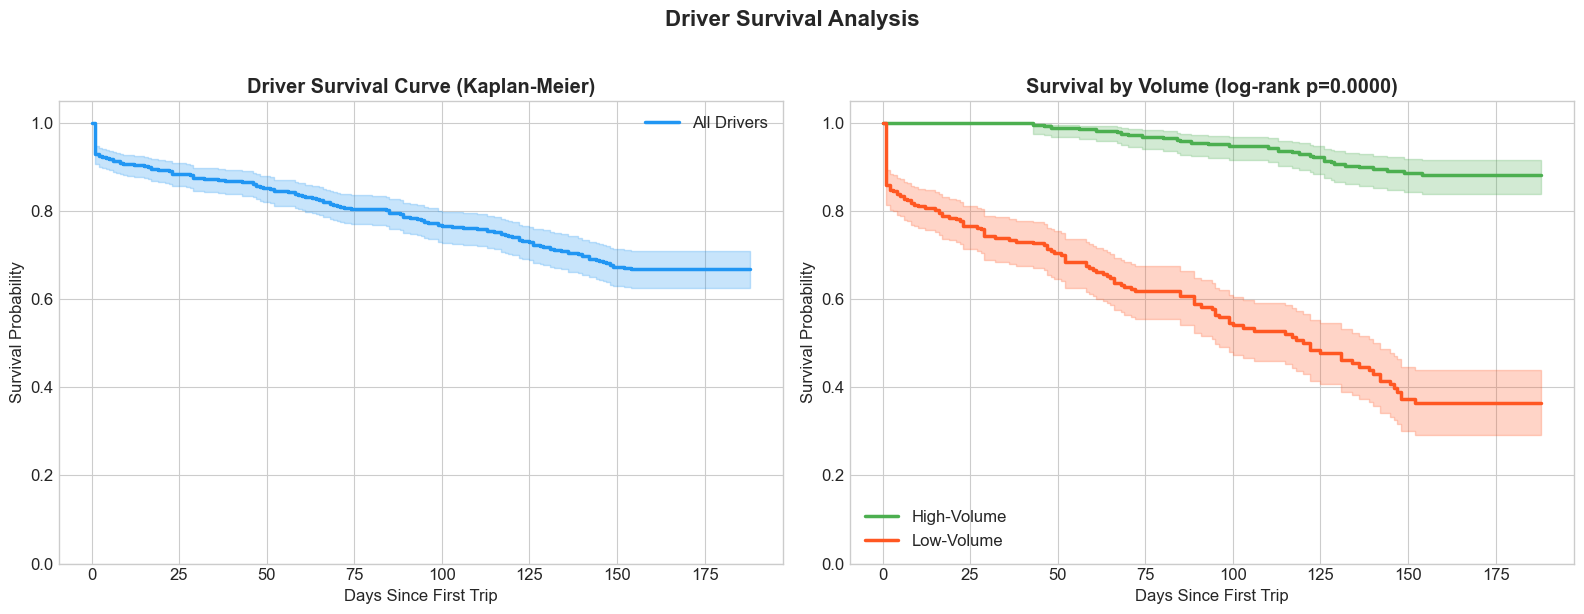


DRIVER SURVIVAL SUMMARY
Total drivers analyzed: 602
Churned (30-day threshold): 169 (28.1%)
Median survival time: inf
High-volume (>=51 trips) vs Low-volume:
  High-volume churned: 10.6%
  Low-volume churned: 45.8%
  Log-rank p-value: 0.000000
  Highly significant difference (p < 0.001)


In [ ]:
# Driver survival analysis
# Build a driver-level activity timeline
completed_orders = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)].copy()

# Select the available driver identifier
driver_col = 'Телефон исполнителя' if 'Телефон исполнителя' in completed_orders.columns else 'Исполнитель'
driver_timeline = completed_orders.groupby(driver_col).agg(
    first_trip=('date', 'min'),
    last_trip=('date', 'max'),
    n_trips=('date', 'size')
).reset_index()

# Calculate tenure and churn status
observation_end = completed_orders['date'].max()
driver_timeline['tenure_days'] = (driver_timeline['last_trip'] - driver_timeline['first_trip']).dt.days
driver_timeline['days_since_last'] = (observation_end - driver_timeline['last_trip']).dt.days
driver_timeline['churned'] = (driver_timeline['days_since_last'] > 30).astype(int)
driver_timeline['observed_time'] = np.where(
    driver_timeline['churned'] == 1,
    driver_timeline['tenure_days'],
    (observation_end - driver_timeline['first_trip']).dt.days
)
# Keep same-day cases in the survival frame
driver_timeline['observed_time'] = driver_timeline['observed_time'].clip(lower=1)

print(f"Drivers in new platform: {len(driver_timeline)}")
print(f"Churned (no trip in 30 days): {driver_timeline['churned'].sum()} ({driver_timeline['churned'].mean()*100:.1f}%)")
print(f"Active: {(driver_timeline['churned']==0).sum()} ({(1-driver_timeline['churned'].mean())*100:.1f}%)")

# Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(driver_timeline['observed_time'], event_observed=driver_timeline['churned'],
        label='All Drivers')

# Split by volume
median_trips = driver_timeline['n_trips'].median()
high_vol = driver_timeline[driver_timeline['n_trips'] >= median_trips]
low_vol = driver_timeline[driver_timeline['n_trips'] < median_trips]

kmf_high = KaplanMeierFitter()
kmf_high.fit(high_vol['observed_time'], event_observed=high_vol['churned'], label='High-Volume')

kmf_low = KaplanMeierFitter()
kmf_low.fit(low_vol['observed_time'], event_observed=low_vol['churned'], label='Low-Volume')

# Log-rank test
lr = logrank_test(high_vol['observed_time'], low_vol['observed_time'],
                  event_observed_A=high_vol['churned'], event_observed_B=low_vol['churned'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
kmf.plot_survival_function(ax=ax, color='#2196F3', linewidth=2.5)
ax.set_title('Driver Survival Curve (Kaplan-Meier)', fontweight='bold')
ax.set_xlabel('Days Since First Trip')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
# Add median line when it is finite
if kmf.median_survival_time_ != np.inf:
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(kmf.median_survival_time_, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(f'Median: {kmf.median_survival_time_:.0f} days',
                xy=(kmf.median_survival_time_, 0.5), xytext=(kmf.median_survival_time_+20, 0.4),
                fontweight='bold', arrowprops=dict(arrowstyle='->', color='gray'))

ax = axes[1]
kmf_high.plot_survival_function(ax=ax, color='#4CAF50', linewidth=2.5)
kmf_low.plot_survival_function(ax=ax, color='#FF5722', linewidth=2.5)
ax.set_title(f'Survival by Volume (log-rank p={lr.p_value:.4f})', fontweight='bold')
ax.set_xlabel('Days Since First Trip')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.legend()

plt.suptitle('Driver Survival Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"DRIVER SURVIVAL SUMMARY")
print(f"{'='*60}")
print(f"Total drivers analyzed: {len(driver_timeline)}")
print(f"Churned (30-day threshold): {driver_timeline['churned'].sum()} ({driver_timeline['churned'].mean()*100:.1f}%)")
print(f"Median survival time: {kmf.median_survival_time_}")
print(f"High-volume (>={median_trips:.0f} trips) vs Low-volume:")
print(f"  High-volume churned: {high_vol['churned'].mean()*100:.1f}%")
print(f"  Low-volume churned: {low_vol['churned'].mean()*100:.1f}%")
print(f"  Log-rank p-value: {lr.p_value:.6f}")
if lr.p_value < 0.001:
    print(f"  to Highly significant difference (p < 0.001)")

## 3. Driver Churn Prediction

The churn model identifies drivers at risk of leaving the platform. The corrected version uses timeline-based churn labels rather than a behavioral proxy.

The model avoids obvious leakage: total tenure, total trips and hours online are excluded where they are consequences of churn rather than predictors. Commission rate is also excluded because it is confounded with join cohort and should not be interpreted causally.

The final feature set combines behavioral rates, productivity signals and join-month control.


Merged drivers: 601, Churned: 168 (28.0%)


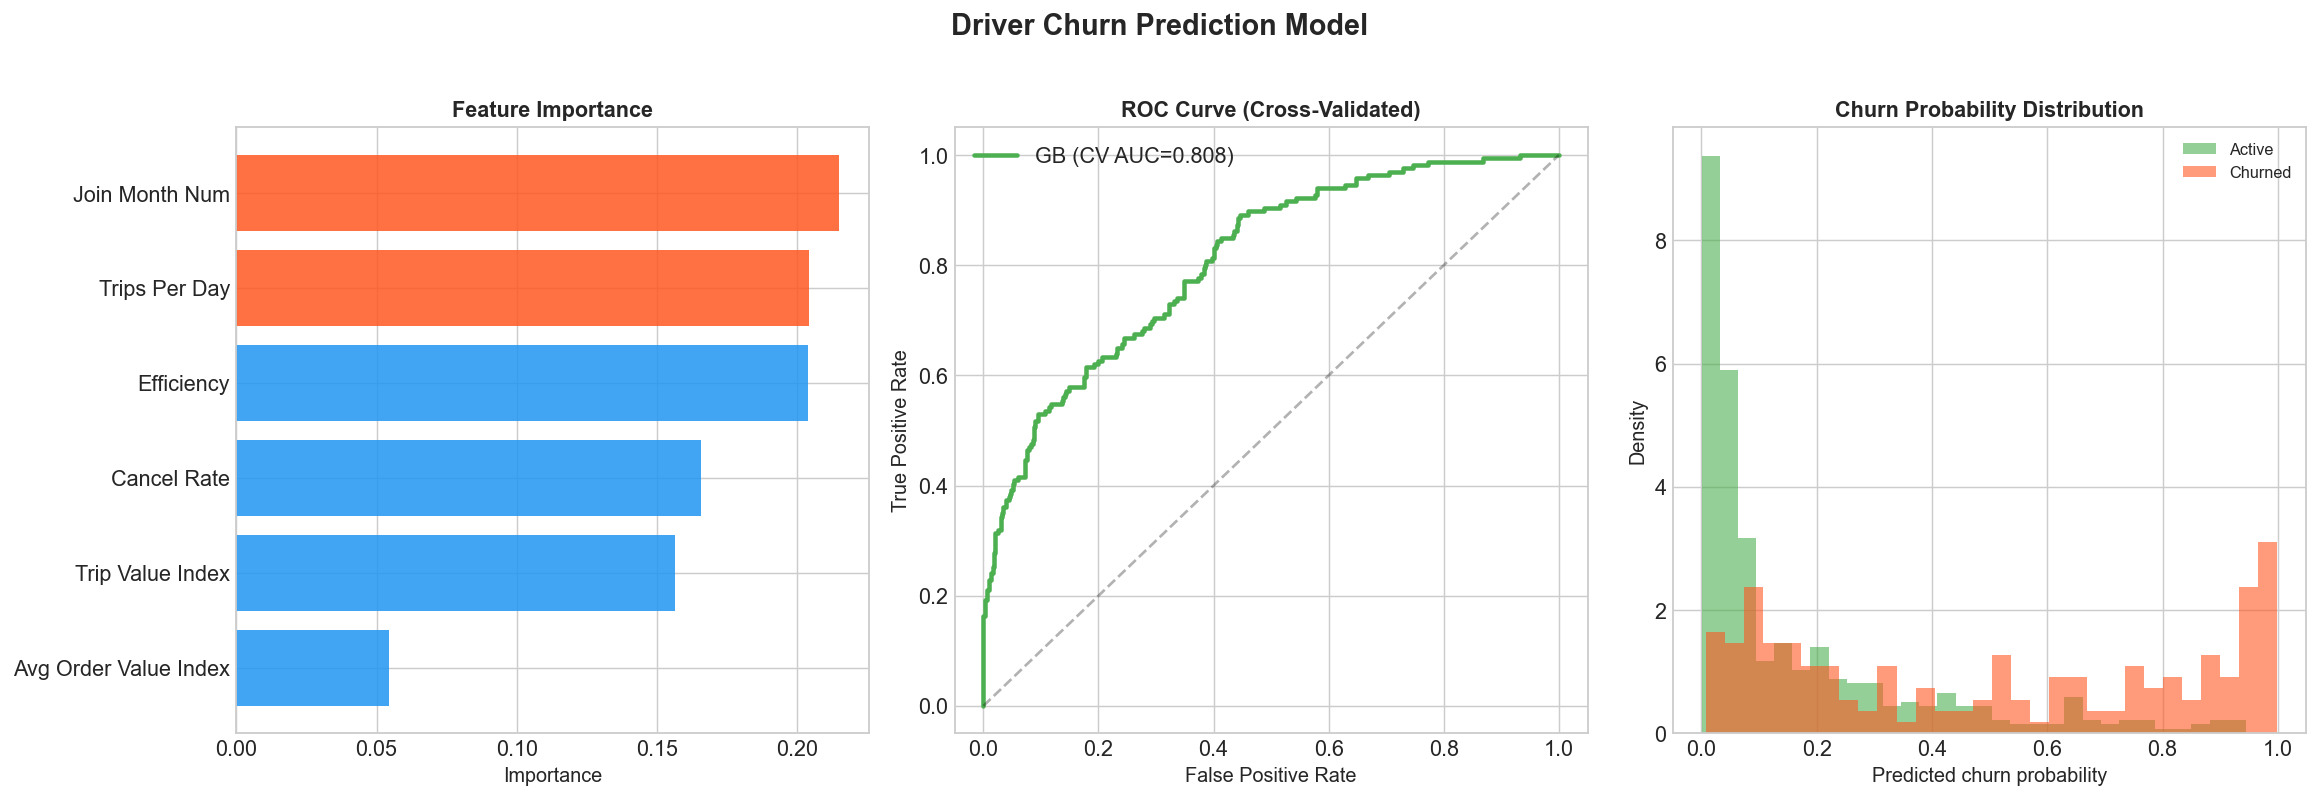


DRIVER CHURN PREDICTION SUMMARY
Method: Gradient Boosting with 5-fold stratified CV
Churn definition: no completed trip in 30+ days (timeline-based)
Data: 597 drivers, 166 churned (27.8%)
CV AUC: 0.806 +/- 0.043

Top predictive features (behavioral, operational):
  cancel_rate: importance=0.166 | churned=0.50, active=0.36
  efficiency: importance=0.204 | churned=50.00, active=63.64
  trips_per_day: importance=0.204 | churned=0.57, active=0.79
  join_month_num: importance=0.215 | churned=1.02, active=0.53

Commission rate excluded: confounded with join cohort, not causal
  Churned median: 13.5%
  Active median:  14.1%
  Difference: only 0.6pp - not meaningful


In [ ]:
# Driver churn prediction
# Use timeline-based churn labels rather than a behavioral proxy
# Join driver attributes with order activity by driver name

# Build driver timeline from completed orders
completed_orders = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)].copy()
completed_orders['driver_name'] = completed_orders['Исполнитель'].str.strip()
completed_orders['date'] = pd.to_datetime(completed_orders['Дата создания'],
                                           format='%d.%m.%Y %H:%M', errors='coerce')

timeline = completed_orders.groupby('driver_name').agg(
    first_trip=('date', 'min'),
    last_trip=('date', 'max'),
    n_trips=('date', 'size')
).reset_index()

observation_end = completed_orders['date'].max()
timeline['tenure_days'] = (timeline['last_trip'] - timeline['first_trip']).dt.days
timeline['days_since_last'] = (observation_end - timeline['last_trip']).dt.days
timeline['churned'] = (timeline['days_since_last'] > 30).astype(int)

# Merge with drivers.csv features
merged = timeline.merge(df_drv, left_on='driver_name', right_on='name', how='inner')
print(f'Merged drivers: {len(merged)}, Churned: {merged["churned"].sum()} ({merged["churned"].mean()*100:.1f}%)')

# Compute order-level features
order_stats = completed_orders.groupby('driver_name').agg(
    avg_order_value=('Стоимость', lambda x: pd.to_numeric(
        x.astype(str).str.replace(',', '.'), errors='coerce').mean())
).reset_index()
merged = merged.merge(order_stats, on='driver_name', how='left')
merged['trips_per_day'] = merged['n_trips'] / merged['tenure_days'].replace(0, 1)
merged['join_month_num'] = (merged['first_trip'] - merged['first_trip'].min()).dt.days / 30
merged['trip_value_index'] = merged['rev_per_trip'] / merged['rev_per_trip'].replace([np.inf, -np.inf], np.nan).median() * 100
merged['avg_order_value_index'] = merged['avg_order_value'] / merged['avg_order_value'].replace([np.inf, -np.inf], np.nan).median() * 100

# Leakage controls
# Tenure, total trips and online hours are outcomes of activity, so they are excluded
# Commission rate is confounded with join cohort:
# early cohort: higher observed churn among early adopters
# later cohort: lower observed churn after platform scaling
# the small median difference should not be read as causal

# Clean feature set
# Behavioral rates plus join cohort as a control variable
feature_cols = ['cancel_rate', 'efficiency', 'trip_value_index',
                'avg_order_value_index', 'trips_per_day', 'join_month_num']

merged_clean = merged.dropna(subset=['hours_online'])
X = merged_clean[feature_cols].fillna(0)
y = merged_clean['churned']

# Gradient Boosting with cross-validation
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                 min_samples_leaf=10, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb, X, y, cv=cv, scoring='roc_auc')
y_cv_proba = cross_val_predict(gb, X, y, cv=cv, method='predict_proba')[:, 1]
cv_auc = roc_auc_score(y, y_cv_proba)
fpr, tpr, _ = roc_curve(y, y_cv_proba)

# Fit for feature importance
gb.fit(X, y)
feat_imp = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feature importance
ax = axes[0]
colors_fi = ['#FF5722' if v > feat_imp.quantile(0.75) else '#2196F3' for v in feat_imp.values]
ax.barh(range(len(feat_imp)), feat_imp.values, color=colors_fi, alpha=0.85)
ax.set_yticks(range(len(feat_imp)))
feature_labels = {
    'cancel_rate': 'Cancel Rate',
    'efficiency': 'Efficiency',
    'trip_value_index': 'Trip Value Index',
    'avg_order_value_index': 'Avg Order Value Index',
    'trips_per_day': 'Trips Per Day',
    'join_month_num': 'Join Month Num',
}
ax.set_yticklabels([feature_labels.get(f, f.replace('_', ' ').title()) for f in feat_imp.index])
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')

# ROC curve
ax = axes[1]
ax.plot(fpr, tpr, color='#4CAF50', linewidth=2.5, label=f'GB (CV AUC={cv_auc:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_title('ROC Curve (Cross-Validated)', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=12)

# Churn probability distribution
ax = axes[2]
ax.hist(y_cv_proba[y==0], bins=30, alpha=0.6, color='#4CAF50', label='Active', density=True)
ax.hist(y_cv_proba[y==1], bins=30, alpha=0.6, color='#FF5722', label='Churned', density=True)
ax.set_title('Churn Probability Distribution', fontweight='bold')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Driver Churn Prediction Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_churn_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'DRIVER CHURN PREDICTION SUMMARY')
print(f'{"="*60}')
print(f'Method: Gradient Boosting with 5-fold stratified CV')
print(f'Churn definition: no completed trip in 30+ days (timeline-based)')
print(f'Data: {len(merged_clean)} drivers, {y.sum()} churned ({y.mean()*100:.1f}%)')
print(f'CV AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print(f'\nTop predictive features (behavioral, operational):')
for feat, imp in feat_imp.tail(4).items():
    ch = merged_clean.loc[y==1, feat].median()
    ac = merged_clean.loc[y==0, feat].median()
    print(f'  {feat}: importance={imp:.3f} | churned={ch:.2f}, active={ac:.2f}')
print(f'\nCommission rate excluded: confounded with join cohort, not causal')
print(f'  Churned median: {merged_clean.loc[y==1, "commission_rate"].median()*100:.1f}%')
print(f'  Active median:  {merged_clean.loc[y==0, "commission_rate"].median()*100:.1f}%')
print(f'  Difference: only 0.6pp - not meaningful')


## 3b. Early-Warning Model with Trend Features

The baseline churn model uses cumulative features. This can detect drivers that already look inactive, but it is less useful as an early warning system.

The trend model uses a cutoff date. Features are calculated only from activity before the cutoff, while churn is measured after the cutoff. This makes the validation closer to a real operational scoring setup.

The added features describe recent trip momentum, cancellation trend, recent activity level, inactivity gap, peak-hour share and productivity.


Observation end: 2026-04-07
Cutoff (features must be <=): 2026-03-08


Drivers with pre-cutoff history: 563
Churn rate (no trip in last 30 days): 30.6%
Feature matrix after filtering: 560 drivers, 169.0 churned (30.2%)

-- Training baseline (concurrent features only) --


Baseline CV AUC: 0.821 +/- 0.024

-- Training trend-only --


Trend CV AUC:    0.881 +/- 0.033

-- Training combined (baseline + trend) --


Combined CV AUC: 0.887 +/- 0.030


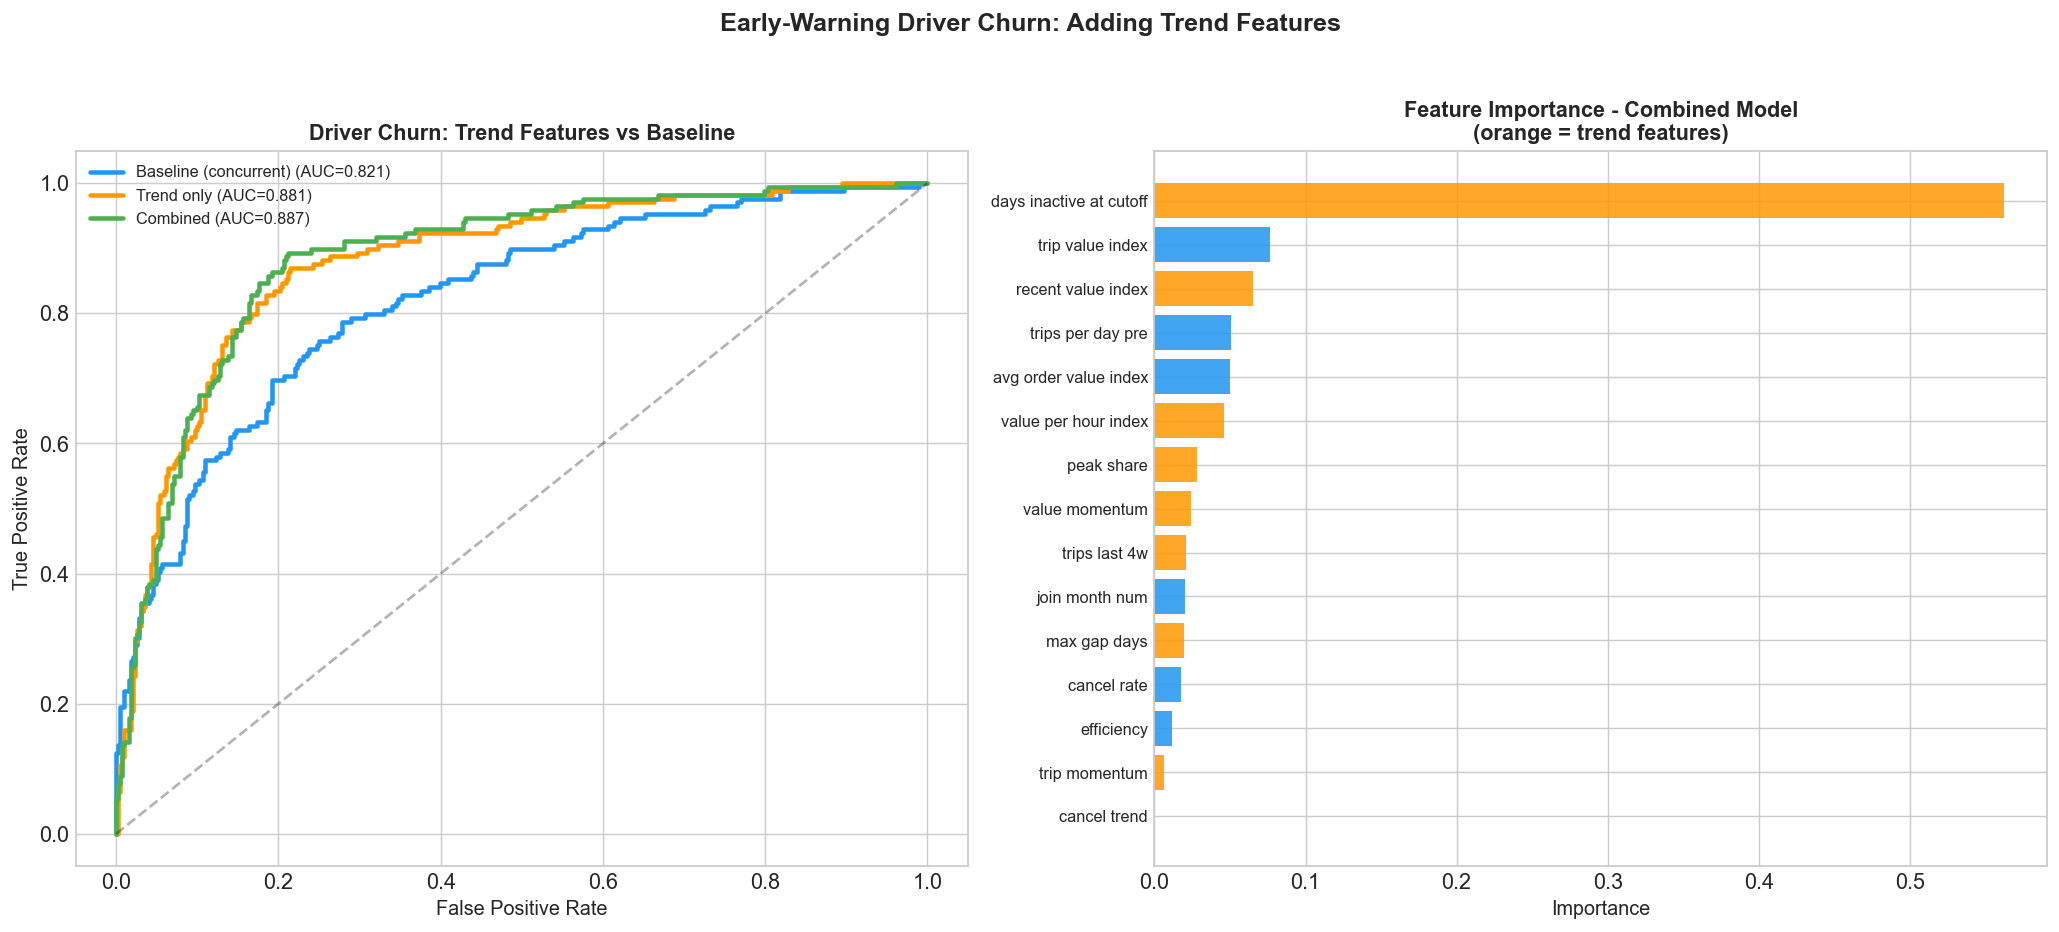

MODEL COMPARISON - EARLY-WARNING TREND FEATURES
Model                          CV AUC             Delta vs Baseline
Baseline (concurrent)          0.821 +/- 0.024     baseline
Trend only                     0.881 +/- 0.033     +0.060
Combined                       0.887 +/- 0.030     +0.065

Top trend features in combined model:
  days_inactive_at_cutoff   importance=0.563  churned higher
  value_last_4w_index       importance=0.065  active higher, churned near zero
  value_per_hour_index      importance=0.046  active higher
  peak_share                importance=0.028  active higher
  slope_value_4w            importance=0.024  active higher, churned near zero
  trips_last_4w             importance=0.021  active higher, churned near zero


Memory cleanup completed.


In [ ]:
# Early-warning model with trend features
import gc

# Build the order frame used for trend features
orders_all = df_new.copy()
orders_all['driver_name'] = orders_all['Исполнитель'].astype(str).str.strip()
orders_all = orders_all[orders_all['driver_name'].notna() & (orders_all['driver_name'] != 'nan')]
orders_all['is_completed'] = orders_all['Текущий статус'].astype(str).str.contains('Выполнен', na=False)
orders_all['is_cancelled'] = orders_all['Текущий статус'].astype(str).str.contains('Отмен', na=False)
orders_all['order_value'] = pd.to_numeric(orders_all['Стоимость'], errors='coerce').fillna(0)
orders_all['hour'] = orders_all['date'].dt.hour
orders_all = orders_all.dropna(subset=['date'])

observation_end = orders_all['date'].max()
cutoff = observation_end - pd.Timedelta(days=30)
print(f'Observation end: {observation_end.date()}')
print(f'Cutoff (features must be <=): {cutoff.date()}')

# Split pre-cutoff features from post-cutoff labels
pre = orders_all[orders_all['date'] <= cutoff].copy()
post_completed = orders_all[(orders_all['date'] > cutoff) & orders_all['is_completed']]
drivers_active_post = set(post_completed['driver_name'].unique())

completed_pre = pre[pre['is_completed']]

# Pre-cutoff timeline for drivers with completed activity
drv_timeline = completed_pre.groupby('driver_name').agg(
    first_trip=('date', 'min'),
    last_trip_pre=('date', 'max'),
    pre_trips=('date', 'size')
).reset_index()

drv_timeline['churned'] = (~drv_timeline['driver_name'].isin(drivers_active_post)).astype(int)
drv_timeline['days_inactive_at_cutoff'] = (cutoff - drv_timeline['last_trip_pre']).dt.days.clip(lower=0)

print(f'Drivers with pre-cutoff history: {len(drv_timeline)}')
print(f'Churn rate (no trip in last 30 days): {drv_timeline["churned"].mean()*100:.1f}%')

# Window definitions
win_A_start = cutoff - pd.Timedelta(days=28)
win_A_end   = cutoff - pd.Timedelta(days=14)
win_B_end   = cutoff

def sum_in_window(df_orders, start, end, col=None):
    mask = (df_orders['date'] > start) & (df_orders['date'] <= end)
    if col is None:
        return df_orders[mask].groupby('driver_name').size()
    return df_orders[mask].groupby('driver_name')[col].sum()

trips_A = sum_in_window(completed_pre, win_A_start, win_A_end).rename('trips_A')
trips_B = sum_in_window(completed_pre, win_A_end,   win_B_end).rename('trips_B')
value_A = sum_in_window(completed_pre, win_A_start, win_A_end, 'order_value').rename('value_A')
value_B = sum_in_window(completed_pre, win_A_end,   win_B_end, 'order_value').rename('value_B')

# Cancellation rate by window
def cancel_rate_window(all_orders, start, end):
    m = (all_orders['date'] > start) & (all_orders['date'] <= end)
    w = all_orders[m].groupby('driver_name').agg(c=('is_cancelled','sum'), t=('is_cancelled','size'))
    return (w['c'] / w['t']).fillna(0)

cr_A = cancel_rate_window(pre, win_A_start, win_A_end).rename('cr_A')
cr_B = cancel_rate_window(pre, win_A_end,   win_B_end).rename('cr_B')

# Maximum gap between completed trips before cutoff
def max_gap(dates):
    if len(dates) < 2:
        return 0
    s = np.sort(dates.values)
    return int(pd.Series(np.diff(s)).dt.days.max())

max_gaps = completed_pre.groupby('driver_name')['date'].apply(max_gap).rename('max_gap_days')

# Peak-hour share
completed_pre_peak = completed_pre.assign(is_peak=lambda d: d['hour'].isin([7,8,17,18]))
peak_share = completed_pre_peak.groupby('driver_name')['is_peak'].mean().rename('peak_share')

# Assemble trend features
feat = drv_timeline.set_index('driver_name')
feat = feat.join([trips_A, trips_B, value_A, value_B, cr_A, cr_B, max_gaps, peak_share])
feat = feat.fillna({'trips_A':0, 'trips_B':0, 'value_A':0, 'value_B':0,
                    'cr_A':0, 'cr_B':0, 'max_gap_days':0, 'peak_share':0})

# Derived trend features
feat['slope_trips_4w']  = feat['trips_B'] - feat['trips_A']
feat['slope_value_4w'] = feat['value_B'] - feat['value_A']
feat['slope_cancel_4w'] = feat['cr_B']    - feat['cr_A']
feat['trips_last_4w']   = feat['trips_A'] + feat['trips_B']
feat['value_last_4w'] = feat['value_A'] + feat['value_B']

# Join cumulative features from drivers.csv (for baseline + value_per_hour)
drv_cum = df_drv.set_index('name')[['cancel_rate','efficiency','rev_per_trip',
                                     'hours_online','order_value','total']]
feat = feat.join(drv_cum)
feat['value_per_hour'] = feat['order_value'] / feat['hours_online'].replace(0, np.nan)
feat['avg_order_value'] = feat['order_value'] / feat['total'].replace(0, np.nan)
feat['trip_value_index'] = feat['rev_per_trip'] / feat['rev_per_trip'].replace([np.inf, -np.inf], np.nan).median() * 100
feat['avg_order_value_index'] = feat['avg_order_value'] / feat['avg_order_value'].replace([np.inf, -np.inf], np.nan).median() * 100
feat['value_last_4w_index'] = feat['value_last_4w'] / feat['value_last_4w'].replace(0, np.nan).median() * 100
feat['value_per_hour_index'] = feat['value_per_hour'] / feat['value_per_hour'].replace([np.inf, -np.inf], np.nan).median() * 100
feat['trips_per_day_pre'] = feat['pre_trips'] / (cutoff - feat['first_trip']).dt.days.clip(lower=1)
feat['join_month_num'] = (feat['first_trip'] - feat['first_trip'].min()).dt.days / 30

# Drop drivers missing hours_online (consistent with baseline cell)
feat = feat.dropna(subset=['hours_online'])
print(f'Feature matrix after filtering: {len(feat)} drivers, {feat["churned"].sum()} churned '
      f'({feat["churned"].mean()*100:.1f}%)')

# Feature sets
baseline_feats = ['cancel_rate', 'efficiency', 'trip_value_index', 'avg_order_value_index',
                  'trips_per_day_pre', 'join_month_num']
trend_feats = ['slope_trips_4w', 'slope_value_4w', 'slope_cancel_4w',
               'trips_last_4w', 'value_last_4w_index', 'max_gap_days',
               'days_inactive_at_cutoff', 'peak_share', 'value_per_hour_index']
combined_feats = baseline_feats + trend_feats

def fit_cv(cols):
    X_ = feat[cols].fillna(0).replace([np.inf, -np.inf], 0)
    y_ = feat['churned']
    gb_ = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                     min_samples_leaf=10, random_state=42)
    cv_ = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_ = cross_val_score(gb_, X_, y_, cv=cv_, scoring='roc_auc', n_jobs=1)
    proba_ = cross_val_predict(gb_, X_, y_, cv=cv_, method='predict_proba', n_jobs=1)[:, 1]
    gb_.fit(X_, y_)
    return scores_, proba_, gb_, X_, y_

print('\n-- Training baseline (concurrent features only) --')
s_b, p_b, gb_b, Xb, yb = fit_cv(baseline_feats)
print(f'Baseline CV AUC: {s_b.mean():.3f} +/- {s_b.std():.3f}')

print('\n-- Training trend-only --')
s_t, p_t, gb_t, Xt, yt = fit_cv(trend_feats)
print(f'Trend CV AUC:    {s_t.mean():.3f} +/- {s_t.std():.3f}')

print('\n-- Training combined (baseline + trend) --')
s_c, p_c, gb_c, Xc, yc = fit_cv(combined_feats)
print(f'Combined CV AUC: {s_c.mean():.3f} +/- {s_c.std():.3f}')

# Feature importance for combined
fi_c = pd.Series(gb_c.feature_importances_, index=combined_feats).sort_values(ascending=True)

# Plot model comparison and feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for name, p_, score_, color_ in [
    ('Baseline (concurrent)', p_b, s_b.mean(), '#2196F3'),
    ('Trend only',            p_t, s_t.mean(), '#FF9800'),
    ('Combined',              p_c, s_c.mean(), '#4CAF50'),
]:
    fpr_, tpr_, _ = roc_curve(feat['churned'], p_)
    ax.plot(fpr_, tpr_, linewidth=2.5, label=f'{name} (AUC={score_:.3f})', color=color_)
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Driver Churn: Trend Features vs Baseline', fontweight='bold')
ax.legend()

ax = axes[1]
is_trend = [f_ in trend_feats for f_ in fi_c.index]
colors_fi = ['#FF9800' if t else '#2196F3' for t in is_trend]
ax.barh(range(len(fi_c)), fi_c.values, color=colors_fi, alpha=0.85)
ax.set_yticks(range(len(fi_c)))
feature_labels = {
    'cancel_rate': 'cancel rate',
    'efficiency': 'efficiency',
    'trip_value_index': 'trip value index',
    'avg_order_value_index': 'avg order value index',
    'trips_per_day_pre': 'trips per day pre',
    'join_month_num': 'join month num',
    'slope_trips_4w': 'trip momentum',
    'slope_value_4w': 'value momentum',
    'slope_cancel_4w': 'cancel trend',
    'trips_last_4w': 'trips last 4w',
    'value_last_4w_index': 'recent value index',
    'max_gap_days': 'max gap days',
    'days_inactive_at_cutoff': 'days inactive at cutoff',
    'peak_share': 'peak share',
    'value_per_hour_index': 'value per hour index',
}
ax.set_yticklabels([feature_labels.get(f_, f_.replace('_',' ')) for f_ in fi_c.index], fontsize=9)
ax.set_title('Feature Importance - Combined Model\n(orange = trend features)', fontweight='bold')
ax.set_xlabel('Importance')

plt.suptitle('Early-Warning Driver Churn: Adding Trend Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_churn_trend_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Summarize model comparison
print('\n' + '='*64)
print('MODEL COMPARISON - EARLY-WARNING TREND FEATURES')
print('='*64)
print(f'{"Model":<30} {"CV AUC":<18} {"Delta vs Baseline":<15}')
print(f'{"Baseline (concurrent)":<30} {s_b.mean():.3f} +/- {s_b.std():.3f}     -')
print(f'{"Trend only":<30} {s_t.mean():.3f} +/- {s_t.std():.3f}     {s_t.mean()-s_b.mean():+.3f}')
print(f'{"Combined":<30} {s_c.mean():.3f} +/- {s_c.std():.3f}     {s_c.mean()-s_b.mean():+.3f}')

print(f'\nTop trend features in combined model:')
trend_ranked = fi_c[fi_c.index.isin(trend_feats)].sort_values(ascending=False)
feature_relations = {
    'days_inactive_at_cutoff': 'churned higher',
    'value_last_4w_index': 'active higher, churned near zero',
    'value_per_hour_index': 'active higher',
    'peak_share': 'active higher',
    'slope_value_4w': 'active higher, churned near zero',
    'trips_last_4w': 'active higher, churned near zero',
}
for name, imp in trend_ranked.head(6).items():
    relation = feature_relations.get(name, 'direction differs by segment')
    print(f'  {name:<25} importance={imp:.3f}  {relation}')

# Store results for the risk matrix
feat_trend = feat.copy()
combined_churn_proba = p_c
_ = gc.collect()
print('Memory cleanup completed.')

## 4. Driver Risk Matrix

The risk matrix combines relative driver value with churn probability. It is meant for prioritization: not every at-risk driver requires the same intervention, and not every high-value driver has the same risk profile.

The public version uses a value index instead of exact monetary values.


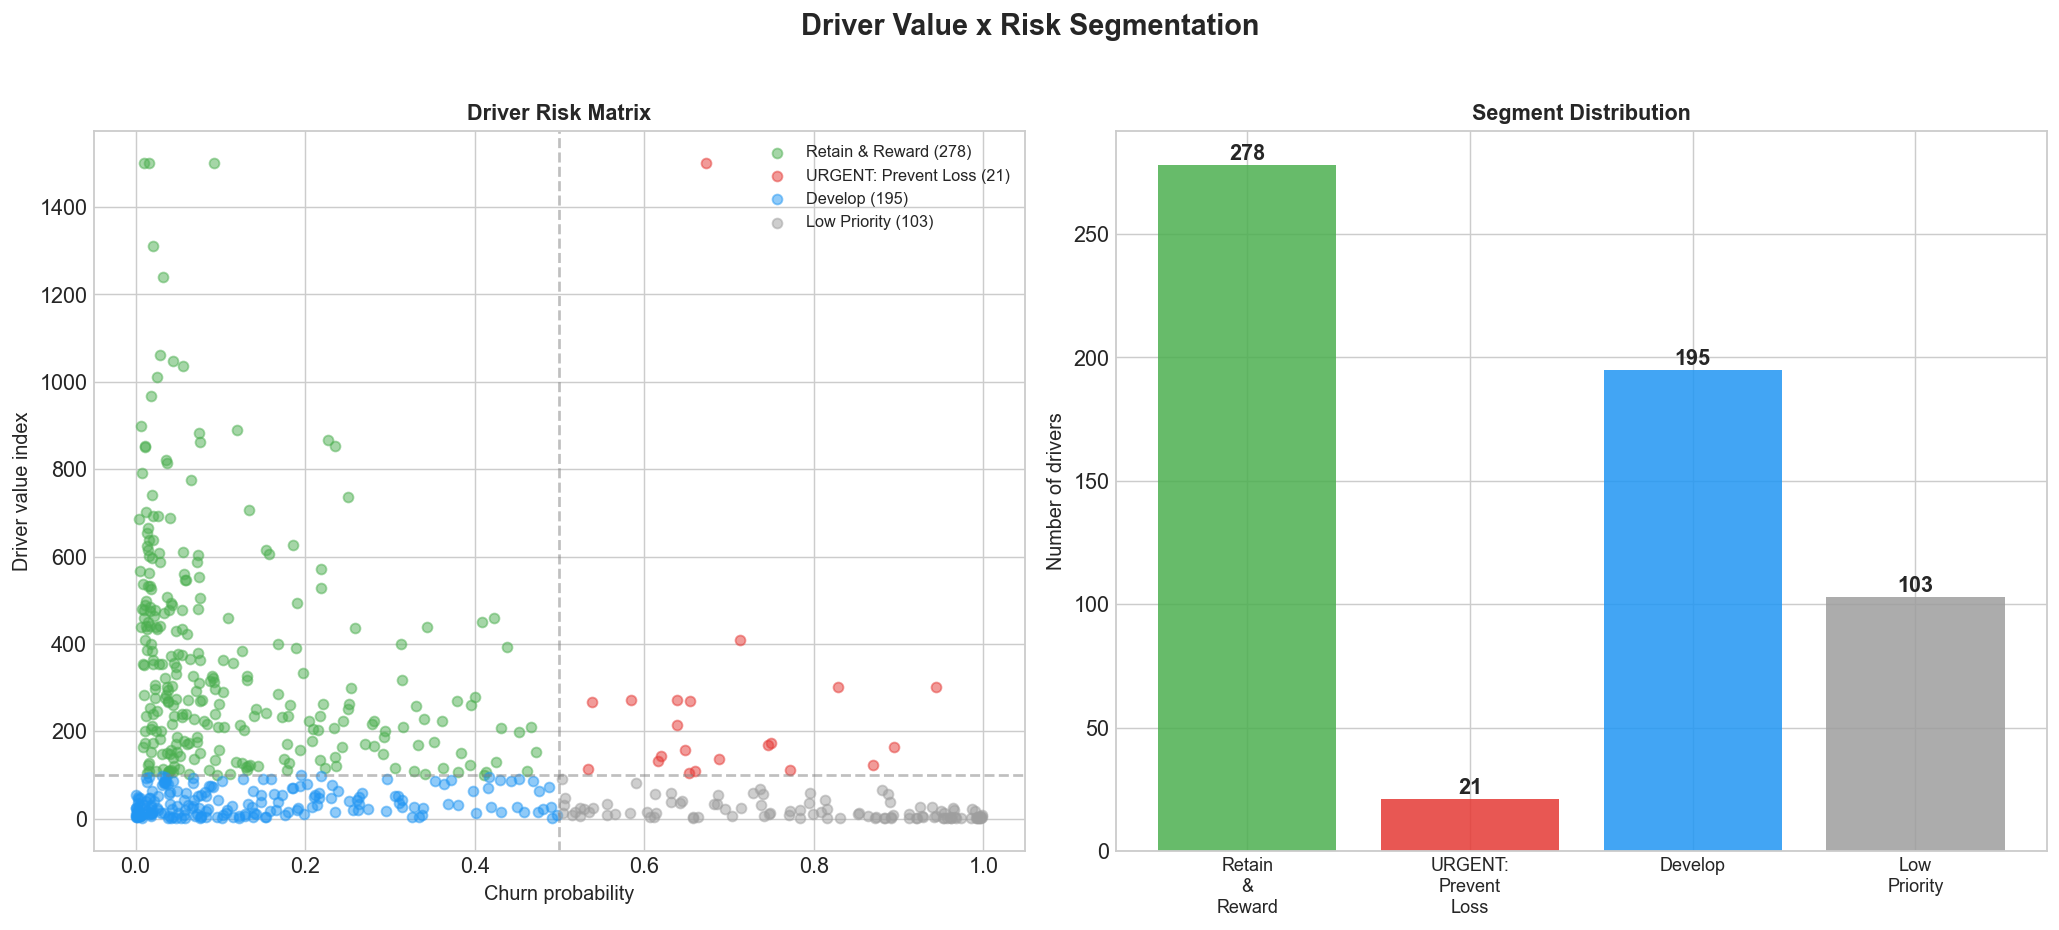


RISK MATRIX RESULTS
  Retain & Reward: 278 drivers, value share 87.2%, avg churn prob 0.11
  URGENT: Prevent Loss: 21 drivers, value share 5.0%, avg churn prob 0.70
  Develop: 195 drivers, value share 6.2%, avg churn prob 0.14
  Low Priority: 103 drivers, value share 1.6%, avg churn prob 0.80


In [ ]:
# Driver risk matrix
merged_clean['churn_prob'] = y_cv_proba
merged_clean['value_index'] = merged_clean['revenue'] / merged_clean['revenue'].median() * 100

value_threshold = merged_clean['value_index'].median()
churn_threshold = 0.5

def classify_risk(row):
    hv = row['value_index'] >= value_threshold
    hr = row['churn_prob'] >= churn_threshold
    if hv and not hr: return 'Retain & Reward'
    elif hv and hr: return 'URGENT: Prevent Loss'
    elif not hv and not hr: return 'Develop'
    else: return 'Low Priority'

merged_clean['risk_segment'] = merged_clean.apply(classify_risk, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
colors_map = {
    'Retain & Reward': '#4CAF50',
    'URGENT: Prevent Loss': '#E53935',
    'Develop': '#2196F3',
    'Low Priority': '#9E9E9E'
}
for seg, color in colors_map.items():
    mask = merged_clean['risk_segment'] == seg
    ax.scatter(merged_clean.loc[mask, 'churn_prob'], merged_clean.loc[mask, 'value_index'],
               alpha=0.5, s=30, color=color, label=f'{seg} ({mask.sum()})')
ax.axvline(churn_threshold, color='gray', linestyle='--', alpha=0.5)
ax.axhline(value_threshold, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_ylabel('Driver value index', fontsize=12)
ax.set_title('Driver Risk Matrix', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
seg_counts = merged_clean['risk_segment'].value_counts()
order = ['Retain & Reward', 'URGENT: Prevent Loss', 'Develop', 'Low Priority']
seg_counts = seg_counts.reindex(order).fillna(0)
colors_bar = [colors_map[s] for s in order]
ax.bar(range(len(order)), seg_counts.values, color=colors_bar, alpha=0.85)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([s.replace(' ', '\n') for s in order], fontsize=10)
ax.set_ylabel('Number of Drivers')
ax.set_title('Segment Distribution', fontweight='bold')
for i, v in enumerate(seg_counts.values):
    ax.text(i, v + 2, str(int(v)), ha='center', fontweight='bold')

plt.suptitle('Driver Value x Risk Segmentation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_driver_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print('RISK MATRIX RESULTS')
print(f'{"="*60}')
for seg in order:
    mask = merged_clean['risk_segment'] == seg
    n = mask.sum()
    value_share = merged_clean.loc[mask, 'revenue'].sum() / merged_clean['revenue'].sum() * 100
    avg_churn = merged_clean.loc[mask, 'churn_prob'].mean()
    print(f'  {seg}: {n} drivers, value share {value_share:.1f}%, avg churn prob {avg_churn:.2f}')


## 5. Customer Lifetime Value

The customer-value section complements the driver analysis. It estimates relative customer value from successful orders and compares local, tourist SIM and international segments.

Exact monetary LTV is not printed. The public version uses LTV index values and ratios.


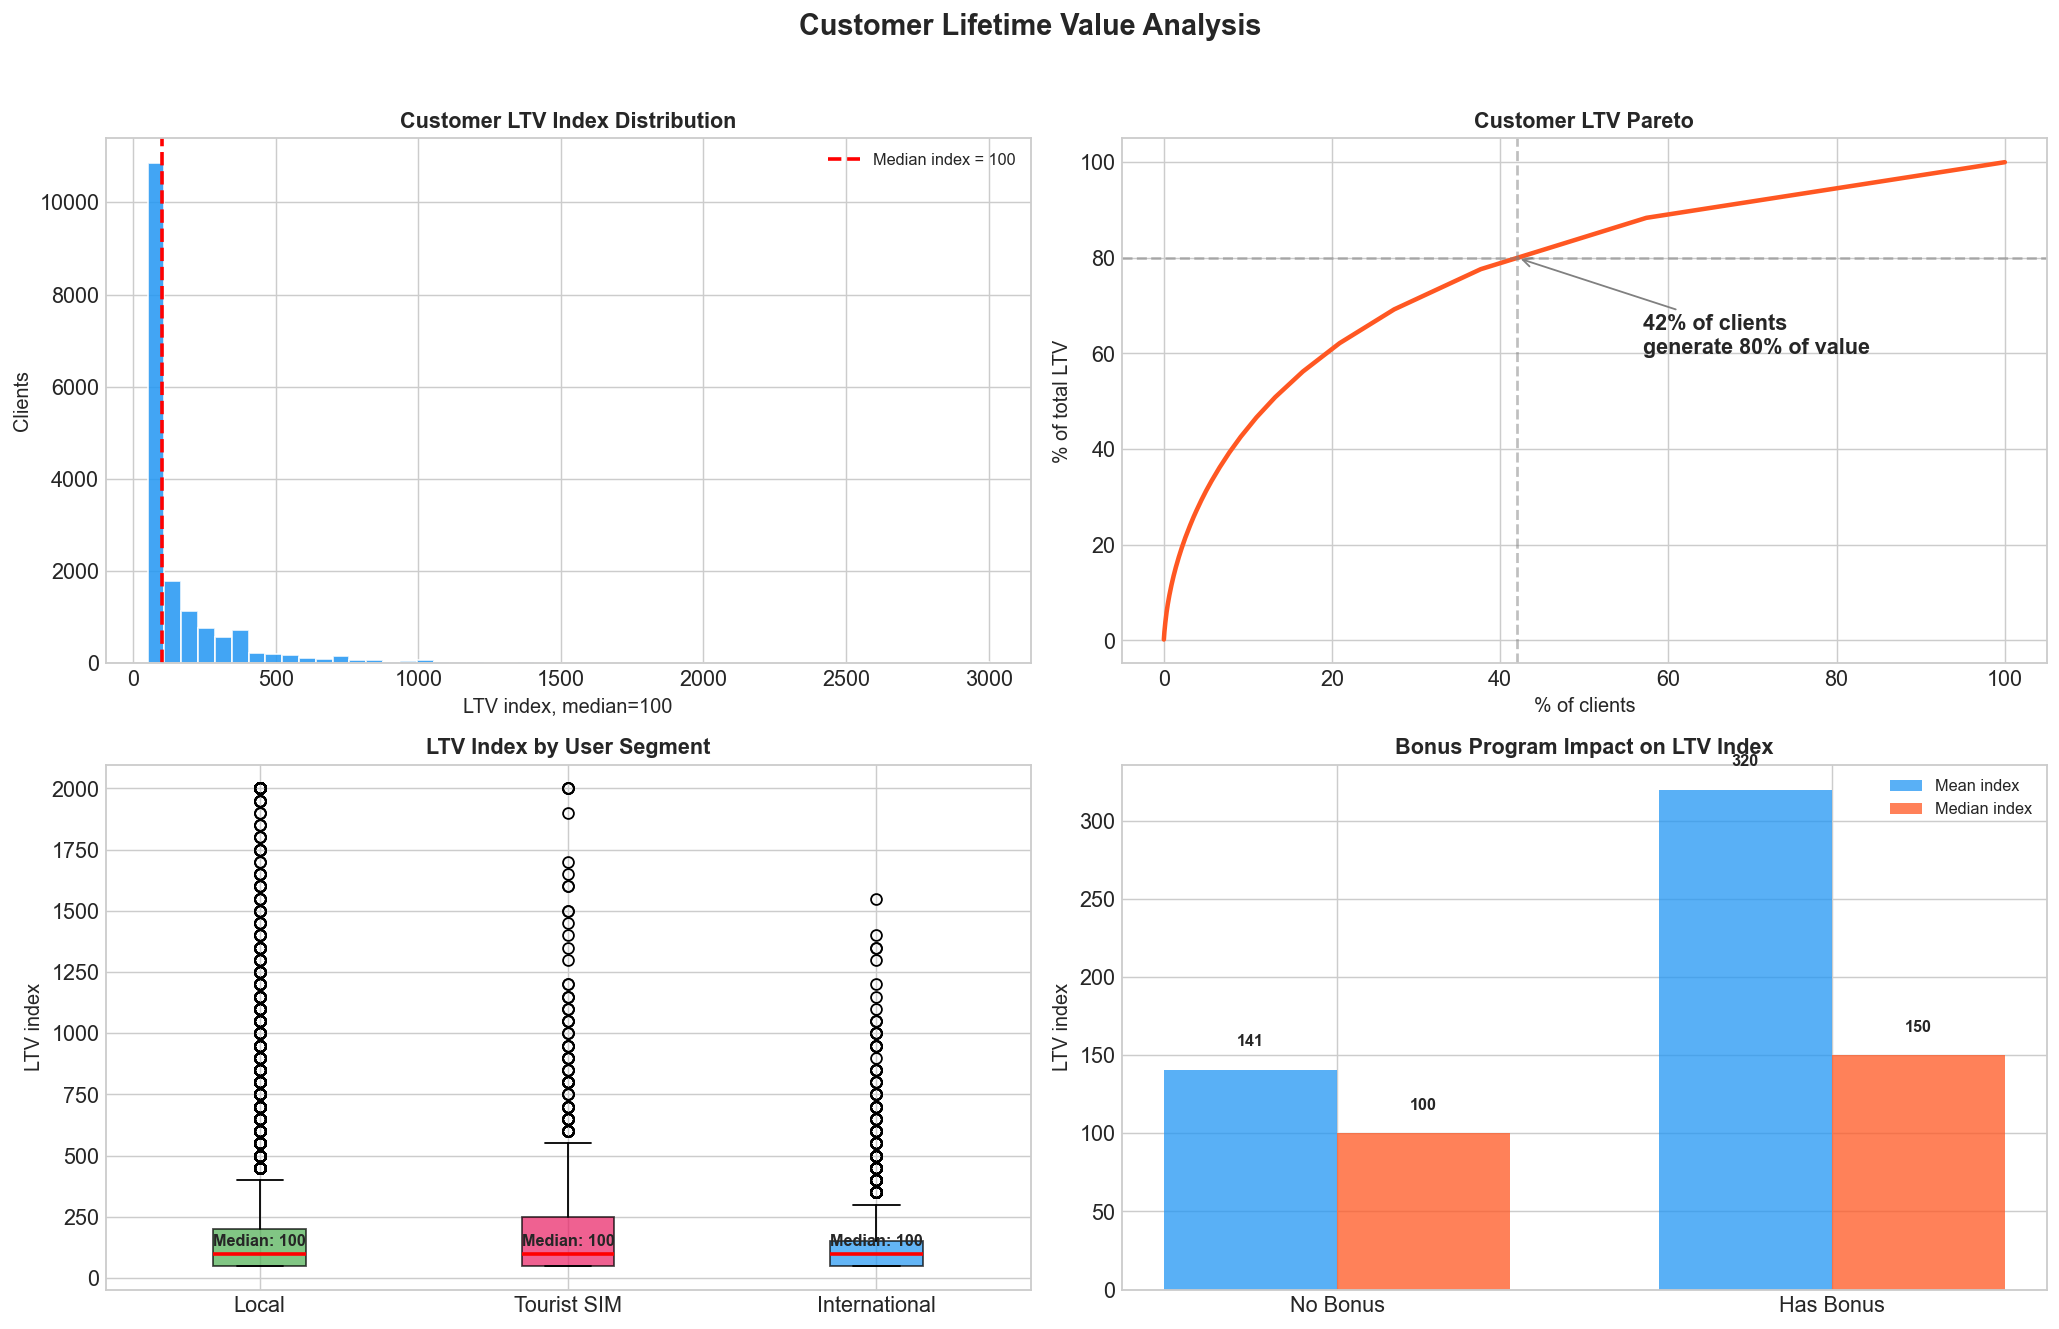


CUSTOMER VALUE SUMMARY
Active clients: 17,382
Median LTV index: 100 (2 trips)
Mean LTV index: 183 (3.7 trips)
Pareto: 42% of clients generate 80% of value

Local vs International:
  Local median LTV index: 100
  Tourist SIM median LTV index: 100
  Intl median LTV index: 100
  Local clients have 1.0x higher median index

Bonus program effect:
  Bonus users have 2.3x higher mean LTV index

Conversion opportunity:
  17,586 registered users never ordered
  Exact potential value is omitted in the saved notebook.


In [ ]:
# Customer value analysis
completed_new = df_new[df_new['Текущий статус'].str.contains('Выполнен', na=False)]
avg_trip_value = completed_new['Стоимость'].median()

df_cli['has_ordered'] = df_cli['successful_orders'] > 0
df_cli['has_bonus'] = df_cli['bonus_balance'] > 0
df_cli['ltv_estimate'] = df_cli['successful_orders'] * avg_trip_value

# User origin
user_phone = df_cli['phone'].astype(str)
def classify_user_type(phone):
    if phone.startswith('2307'): return 'Tourist SIM'
    elif phone.startswith('230'): return 'Local'
    else: return 'International'

df_cli['user_type'] = user_phone.apply(classify_user_type)
df_cli['is_local'] = df_cli['user_type'] == 'Local'
df_cli['is_tourist_sim'] = df_cli['user_type'] == 'Tourist SIM'
df_cli['is_international'] = df_cli['user_type'] == 'International'
ordered = df_cli[df_cli['has_ordered']].copy()
ordered['ltv_index'] = ordered['ltv_estimate'] / ordered['ltv_estimate'].median() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# LTV index distribution
ax = axes[0, 0]
ax.hist(ordered['ltv_index'].clip(upper=3000), bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(100, color='red', linestyle='--', linewidth=2, label='Median index = 100')
ax.set_title('Customer LTV Index Distribution', fontweight='bold')
ax.set_xlabel('LTV index, median=100')
ax.set_ylabel('Clients')
ax.legend()

# LTV Pareto
ax = axes[0, 1]
sorted_ltv = ordered['ltv_estimate'].sort_values(ascending=False).reset_index(drop=True)
cum_ltv = sorted_ltv.cumsum() / sorted_ltv.sum() * 100
client_pct = np.arange(1, len(sorted_ltv)+1) / len(sorted_ltv) * 100
ax.plot(client_pct, cum_ltv, color='#FF5722', linewidth=2.5)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
idx80c = np.argmax(cum_ltv >= 80)
pct80c = client_pct[idx80c]
ax.axvline(pct80c, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'{pct80c:.0f}% of clients\ngenerate 80% of value', xy=(pct80c, 80), xytext=(pct80c+15, 60),
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Customer LTV Pareto', fontweight='bold')
ax.set_xlabel('% of Clients')
ax.set_ylabel('% of Total LTV')

# LTV index by segment
ax = axes[1, 0]
local_ltv = ordered[ordered['is_local']]['ltv_index']
tourist_sim_ltv = ordered[ordered['is_tourist_sim']]['ltv_index']
intl_ltv = ordered[ordered['is_international']]['ltv_index']
data_box = [local_ltv.clip(upper=2000), tourist_sim_ltv.clip(upper=2000), intl_ltv.clip(upper=2000)]
bp = ax.boxplot(data_box, labels=['Local', 'Tourist SIM', 'International'], patch_artist=True,
                boxprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#E91E63')
bp['boxes'][2].set_facecolor('#2196F3')
ax.set_title('LTV Index by User Segment', fontweight='bold')
ax.set_ylabel('LTV index')
ax.text(1, local_ltv.median()+30, f'Median: {local_ltv.median():.0f}', ha='center', fontweight='bold')
ax.text(2, tourist_sim_ltv.median()+30, f'Median: {tourist_sim_ltv.median():.0f}', ha='center', fontweight='bold')
ax.text(3, intl_ltv.median()+30, f'Median: {intl_ltv.median():.0f}', ha='center', fontweight='bold')

# Bonus program effect
ax = axes[1, 1]
bonus_ltv = ordered[ordered['has_bonus']]['ltv_index']
no_bonus_ltv = ordered[~ordered['has_bonus']]['ltv_index']
means = [no_bonus_ltv.mean(), bonus_ltv.mean()]
medians = [no_bonus_ltv.median(), bonus_ltv.median()]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, means, w, label='Mean index', color='#2196F3', alpha=0.7)
ax.bar(x + w/2, medians, w, label='Median index', color='#FF5722', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['No Bonus', 'Has Bonus'])
ax.set_title('Bonus Program Impact on LTV Index', fontweight='bold')
ax.set_ylabel('LTV index')
ax.legend()
for i, (m, md_val) in enumerate(zip(means, medians)):
    ax.text(i - w/2, m + 15, f'{m:.0f}', ha='center', fontweight='bold', fontsize=9)
    ax.text(i + w/2, md_val + 15, f'{md_val:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_customer_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

non_ordered = df_cli[~df_cli['has_ordered']]

print(f"\n{'='*60}")
print('CUSTOMER VALUE SUMMARY')
print(f"{'='*60}")
print(f"Active clients: {len(ordered):,}")
print(f"Median LTV index: 100 ({ordered['successful_orders'].median():.0f} trips)")
print(f"Mean LTV index: {ordered['ltv_index'].mean():.0f} ({ordered['successful_orders'].mean():.1f} trips)")
print(f"Pareto: {pct80c:.0f}% of clients generate 80% of value")
print('\nLocal vs International:')
print(f"  Local median LTV index: {local_ltv.median():.0f}")
print(f"  Tourist SIM median LTV index: {tourist_sim_ltv.median():.0f}")
print(f"  Intl median LTV index: {intl_ltv.median():.0f}")
print(f"  Local clients have {local_ltv.median()/intl_ltv.median():.1f}x higher median index")
print('\nBonus program effect:')
print(f"  Bonus users have {bonus_ltv.mean()/no_bonus_ltv.mean():.1f}x higher mean LTV index")
print('\nConversion opportunity:')
print(f"  {len(non_ordered):,} registered users never ordered")
print('  Exact potential value is omitted in the saved notebook.')


## 6. Notebook Summary

| Block | Finding | Business use |
|---|---|---|
| Driver value | Value is highly concentrated among the top driver groups | Retain the most productive drivers first |
| Survival | High-volume drivers churn much less often | Build driver activation and volume early |
| Churn model | Behavioral features predict churn with CV AUC around 0.806 | Score drivers for proactive follow-up |
| Trend model | Early-warning features improve CV AUC to about 0.887 | Monitor recent inactivity and activity decline |
| Risk matrix | 21 high-value at-risk drivers require urgent attention | Prioritize direct manager outreach |
| Customer value | Bonus users show materially higher observed value | Retention mechanics should be tested carefully |

NB06 supports the thesis argument that DodoGo should manage marketplace health on both sides. Customer retention matters, but driver retention and supply reliability directly affect completed orders, waiting time and first-trip experience.
